In [1]:
import os; cwd = os.getcwd(); print("Current Working Directory:", cwd)

Current Working Directory: /home/jupyter-vruiz/gdrive_TomogramDenoising/deenoising/docs/DAE/cryoCARE/Experimento_saltoZ/epfl_30nm_linear_interpolation/even_odd_registered


In [2]:
from pathlib import Path
from collections import namedtuple
import json

In [3]:
Args = namedtuple("args", ["original", "even", "odd", "even_reg", "odd_reg", "denoised"])
args = Args("/home/jupyter-vruiz/gdrive_Tomograms/epfl_30nm.mrc", "../even_odd/even.mrc", "../even_odd/odd.mrc", "even_registered.mrc", "odd_registered.mrc",  "denoised_vol/epfl_30nm.mrc")

In [4]:
if Path(args.denoised).exists():
    raise Exception(f"{args.denoised} already exists ... exiting")

In [5]:
if not Path(args.even).exists() or not Path(args.odd):
    %run ../even_odd/split_even_odd.ipynb
    Args = namedtuple("args", ["original", "even", "odd", "even_reg", "odd_reg", "denoised"])
    args = Args("/home/jupyter-vruiz/gdrive_Tomograms/epfl_30nm.mrc", "../even_odd/even.mrc", "../even_odd/odd.mrc", "even_registered.mrc", "odd_registered.mrc",  "denoised_vol/epfl_30nm.mrc")

In [6]:
if not Path(args.even_reg).exists() or not Path(args.odd_reg):
    %run project_odd_even_and_viceversa.ipynb
    Args = namedtuple("args", ["original", "even", "odd", "even_reg", "odd_reg", "denoised"])
    args = Args("/home/jupyter-vruiz/gdrive_Tomograms/epfl_30nm.mrc", "../even_odd/even.mrc", "../even_odd/odd.mrc", "even_registered.mrc", "odd_registered.mrc",  "denoised_vol/epfl_30nm.mrc")

In [7]:
# %pip install tensorflow==2.4

## Configure cryoCARE

%%writefile train_data_config__odd_even_registered.json
{
    "even": ["even.mrc", "odd_registered.mrc"],
    "odd": ["odd.mrc", "even_registered.mrc"],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./odd_even_registered_data",
    "overwrite": "True"  
}

%%writefile train_data_config__odd_even_registered.json
{
    "even": ["even.mrc", "odd_registered.mrc"],
    "odd": ["even_registered.mrc", "odd.mrc"],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./odd_even_registered_data",
    "overwrite": "True"  
}

%%writefile train_data_config__odd_even_registered.json
{
    "even": ["even.mrc", "even_registered.mrc"],
    "odd": ["odd_registered.mrc", "odd.mrc"],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./odd_even_registered_data",
    "overwrite": "True"  
}

%%writefile train_data_config__odd_even_registered.json
{
    "even": ["even.mrc", "odd_registered.mrc"],
    "odd": ["odd.mrc", "even_registered.mrc"],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./odd_even_registered_data",
    "overwrite": "True"  
}

In [8]:
_ = {
    "even": [args.even, args.even_reg],
    "odd": [args.odd_reg, args.odd],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./data",
    "overwrite": "True"  
}

with open("train_data_config.json", 'w') as f:
    json.dump(_, f, indent=4)

In [9]:
!cat train_data_config.json

{
    "even": [
        "../even_odd/even.mrc",
        "even_registered.mrc"
    ],
    "odd": [
        "odd_registered.mrc",
        "../even_odd/odd.mrc"
    ],
    "mask": [
        ""
    ],
    "patch_shape": [
        16,
        16,
        16
    ],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./data",
    "overwrite": "True"
}

%%writefile train_data_config__odd_even_registered.json
{
    "even": ["even_registered.mrc", "even.mrc"],
    "odd": ["odd.mrc", "odd_registered.mrc"],
    "mask": [""],
    "patch_shape": [16, 16, 16],
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./odd_even_registered_data",
    "overwrite": "True"  
}

In [10]:
%%bash
#cd /nas/vruiz/cryoCARE/empiar11415
source ~/envs/cryoCARE/bin/activate
cryoCARE_extract_train_data.py --conf train_data_config.json

2026-06-06 09:15:51.343980: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
/home/jupyter-vruiz/envs/cryoCARE/lib/python3.8/site-packages/google/api_core/_python_version_support.py:237: FutureWarning: You are using a non-supported Python version (3.8.19). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)


An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'
even.data.shape=(75, 1024, 1024), sample_shape=[16, 16, 16]
even.data.shape=(75, 1024, 1024), sample_shape=[16, 16, 16]
Computing normalization parameters:


100%|██████████| 200/200 [00:01<00:00, 138.68it/s]


## Train

In [11]:
%%writefile train_config.json
{
  "train_data": "./data",
  "epochs": 50,
  "steps_per_epoch": 200,
  "batch_size": 16,
  "unet_kern_size": 3,
  "unet_n_depth": 3,
  "unet_n_first": 16,
  "learning_rate": 0.0004,
  "model_name": "model",
  "path": "./",
  "gpu_id": [0]
}

Writing train_config.json


In [12]:
%%bash
#cd /nas/vruiz/cryoCARE/empiar11415
source ~/envs/cryoCARE/bin/activate
cryoCARE_train.py --conf train_config.json

2026-06-06 09:16:01.199450: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2026-06-06 09:16:05.399674: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2026-06-06 09:16:05.400519: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2026-06-06 09:16:05.425834: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-06 09:16:05.427223: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:c1:00.0 name: NVIDIA A30 computeCapability: 8.0
coreClock: 1.44GHz coreCount: 56 deviceMemorySize: 23.60GiB deviceMemoryBandwidth: 869.04GiB/s
2026-06-06 09:16:05.427307: I tensorflow/stream_executor/cuda/cuda_gpu_executor.c

An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'
Looking for GPU with ID: 0
GPU 0 successfully found
0 1
1 16
2 16
3 16
4 1
Epoch 1/50


2026-06-06 09:16:11.357440: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.8
2026-06-06 09:16:13.220990: W tensorflow/stream_executor/gpu/asm_compiler.cc:63] Running ptxas --version returned 256
2026-06-06 09:16:13.322056: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: ptxas exited with non-zero error code 256, output: 
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-06-06 09:16:14.480064: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11
2026-06-06 09:16:14.975228: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.11
2026-06-06 09:16:32.116189: I tensorflow/stream_executor/cuda/cuda_blas.cc:1838] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
20

200/200 [==============================] - 68s 136ms/step - loss: 0.3659 - mse: 0.3659 - mae: 0.4670 - val_loss: 0.3543 - val_mse: 0.3543 - val_mae: 0.4575
Epoch 2/50
200/200 [==============================] - 4s 20ms/step - loss: 0.3216 - mse: 0.3216 - mae: 0.4375 - val_loss: 0.3456 - val_mse: 0.3456 - val_mae: 0.4521
Epoch 3/50
200/200 [==============================] - 4s 20ms/step - loss: 0.3183 - mse: 0.3183 - mae: 0.4351 - val_loss: 0.3373 - val_mse: 0.3373 - val_mae: 0.4462
Epoch 4/50
200/200 [==============================] - 4s 20ms/step - loss: 0.3157 - mse: 0.3157 - mae: 0.4331 - val_loss: 0.3427 - val_mse: 0.3427 - val_mae: 0.4496
Epoch 5/50
200/200 [==============================] - 4s 21ms/step - loss: 0.3132 - mse: 0.3132 - mae: 0.4314 - val_loss: 0.3372 - val_mse: 0.3372 - val_mae: 0.4477
Epoch 6/50
200/200 [==============================] - 4s 21ms/step - loss: 0.3147 - mse: 0.3147 - mae: 0.4324 - val_loss: 0.3397 - val_mse: 0.3397 - val_mae: 0.4483
Epoch 7/50
200/200 

## Infer

In [13]:
_ = {
    "path": "./model.tar.gz",
    "even": [args.original], 
    "odd": [args.original],
    "n_tiles": [1,4,4],
    "output": "denoised_vol",
    "overwrite": "True",
    "gpu_id": [0]
}

with open("predict_config.json", 'w') as f:
    json.dump(_, f, indent=4)

In [14]:
!cat predict_config.json

{
    "path": "./model.tar.gz",
    "even": [
        "/home/jupyter-vruiz/gdrive_Tomograms/epfl_30nm.mrc"
    ],
    "odd": [
        "/home/jupyter-vruiz/gdrive_Tomograms/epfl_30nm.mrc"
    ],
    "n_tiles": [
        1,
        4,
        4
    ],
    "output": "denoised_vol",
    "overwrite": "True",
    "gpu_id": [
        0
    ]
}

%%writefile predict_config__odd_even_registered.json
{
    "path": "./model.tar.gz",
    "even": ["empiar11415.mrc"], 
    "odd": ["empiar11415.mrc"],
    "n_tiles": [1,2,2],
    "output": "odd_even_registered_denoised",
    "overwrite": "True",
    "gpu_id": [1]
}

In [15]:
%%bash
#cd /nas/vruiz/cryoCARE/empiar11415
#pwd
source ~/envs/cryoCARE/bin/activate
cryoCARE_predict.py --conf predict_config.json || true

2026-06-06 09:20:56.736722: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2026-06-06 09:21:04.239282: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2026-06-06 09:21:04.240976: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2026-06-06 09:21:04.266341: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-06-06 09:21:04.267839: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:c1:00.0 name: NVIDIA A30 computeCapability: 8.0
coreClock: 1.44GHz coreCount: 56 deviceMemorySize: 23.60GiB deviceMemoryBandwidth: 869.04GiB/s
2026-06-06 09:21:04.267903: I tensorflow/stream_executor/cuda/cuda_gpu_executor.c

An error occurred: module 'importlib.metadata' has no attribute 'packages_distributions'
Looking for GPU with ID: 0
GPU 0 successfully found
Loading network weights from 'weights_best.h5'.
(152, 1024, 1024, 1)


100%|██████████| 16/16 [01:19<00:00,  4.99s/it]  


['NEWSTACK: Images copied                                 28-May-26  13:50:17     '
 'NEWSTACK: Images copied                                 28-May-26  13:54:04     '
 '\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 '
 '\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 '
 ' \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 '
 '\x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x00 \x00\x00\x

In [16]:
import mrcfile
import numpy as np
import matplotlib.pyplot as plt

In [17]:
def read_MRC(file_path):
    return mrcfile.read(file_path)

In [18]:
original_vol = read_MRC(args.original)

In [19]:
denoised_vol = read_MRC(args.denoised)

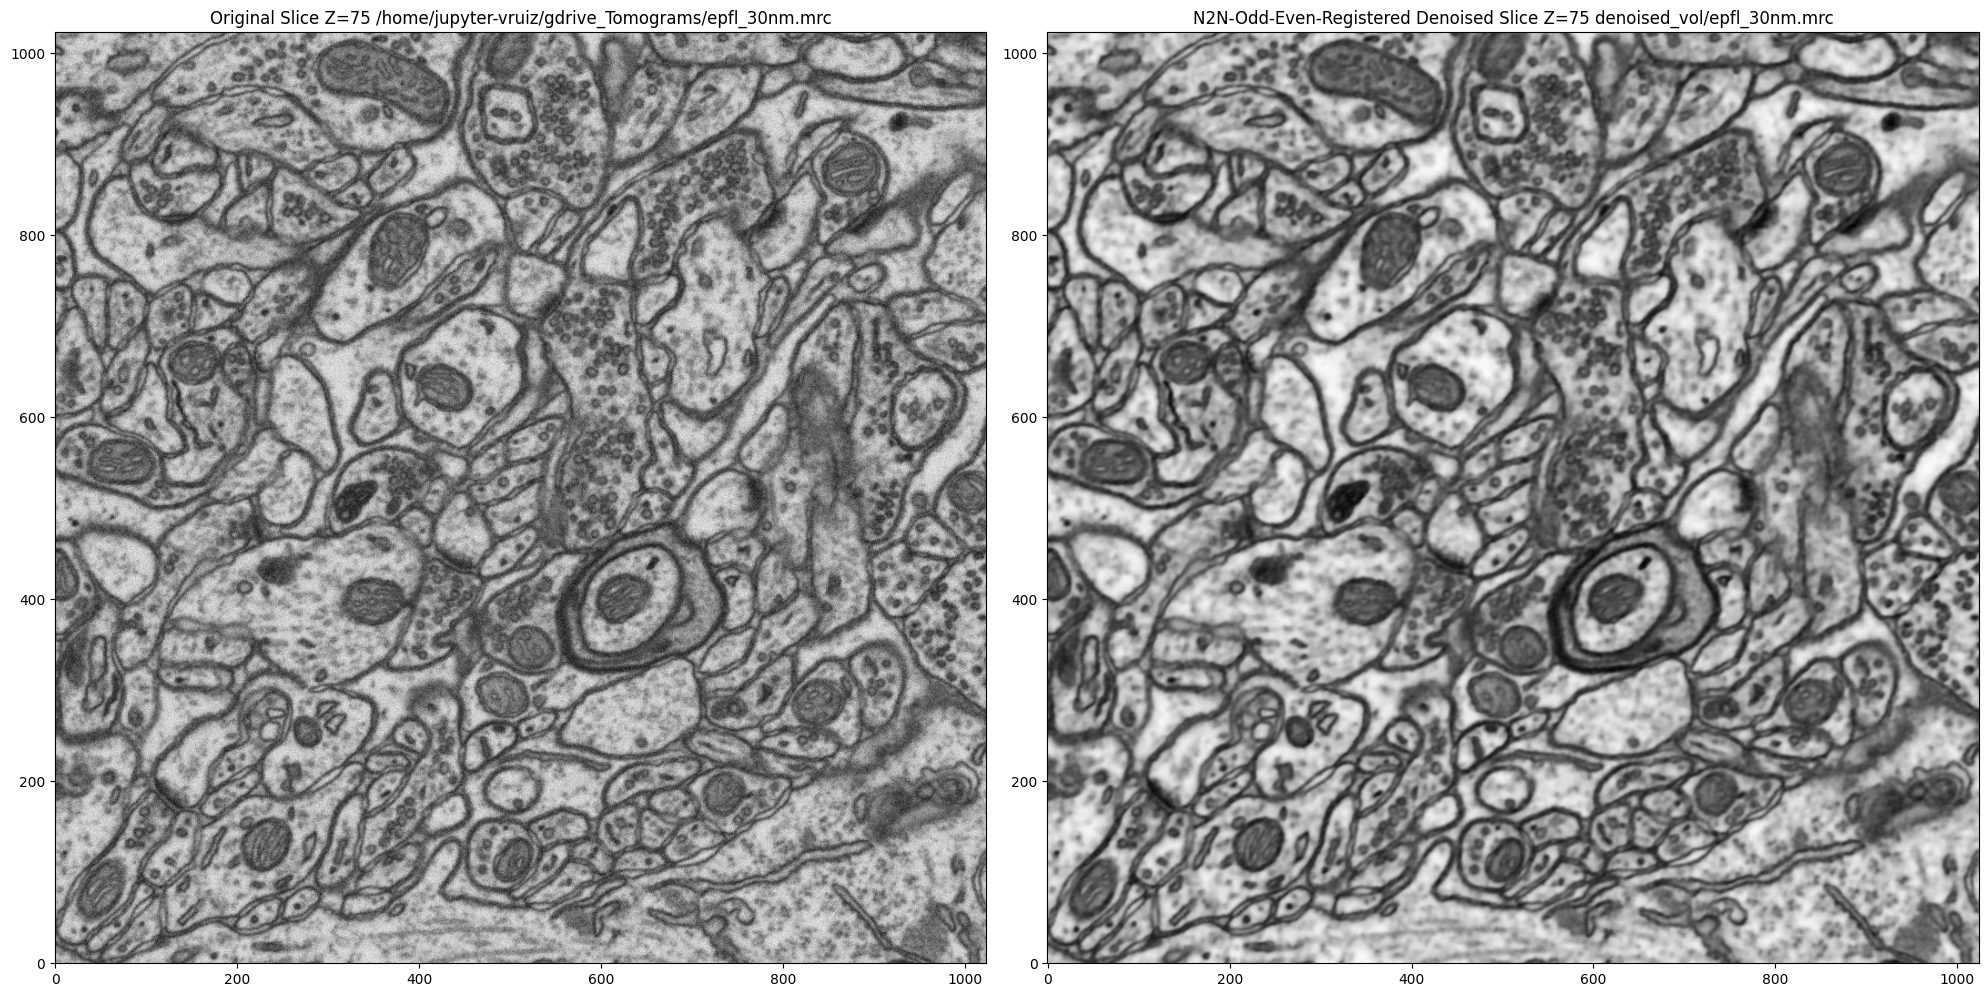

In [20]:
# Choose a slice index in the middle of the volume for a good comparison
slice_idx = original_vol.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(20, 20))

# Plot the original slice z
im1 = axes[0].imshow(original_vol[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx} {args.original}')
axes[0].grid(False)

# Plot the original slice z+1
im2 = axes[1].imshow(denoised_vol[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx} {args.denoised}')
axes[1].grid(False)

plt.tight_layout()
plt.show()

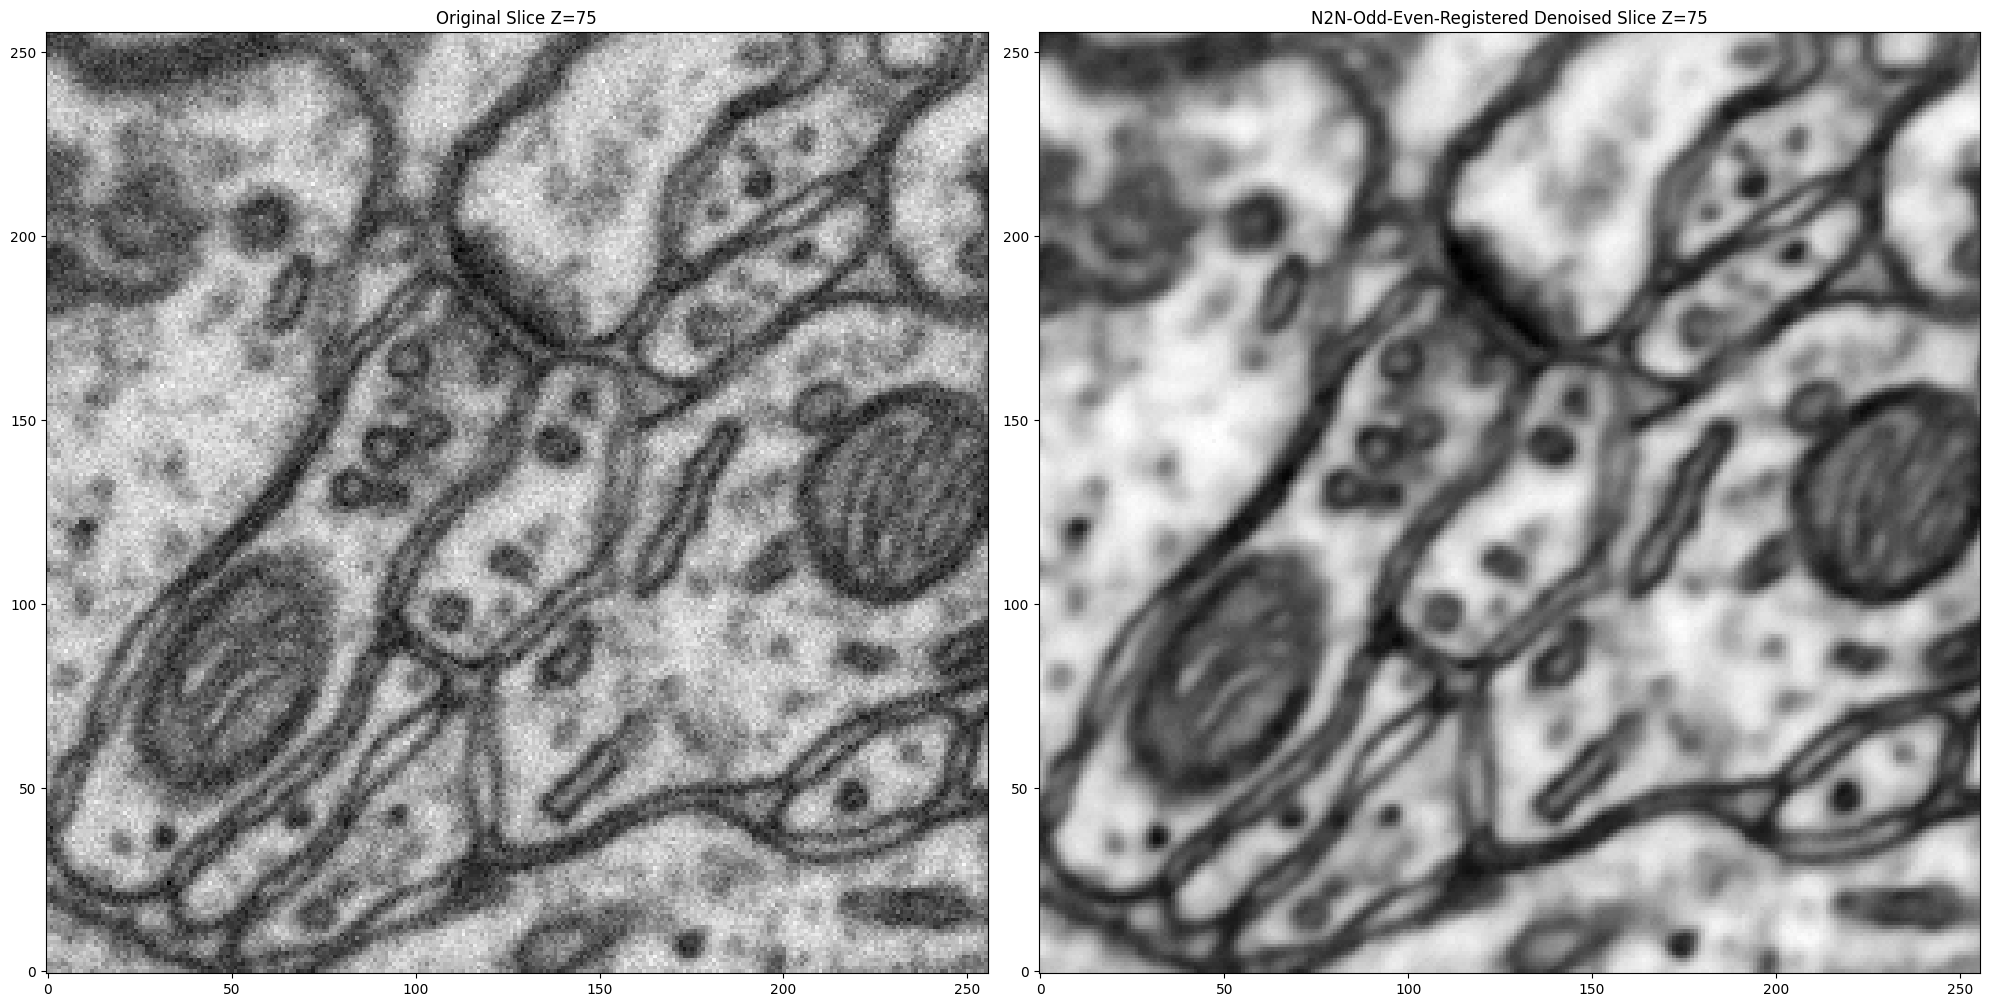

In [21]:
slice_idx = original_vol.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(20, 20))

# Plot the original slice z
im1 = axes[0].imshow(original_vol[slice_idx, :256, :256].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot the original slice z+1
im2 = axes[1].imshow(denoised_vol[slice_idx, :256, :256].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()

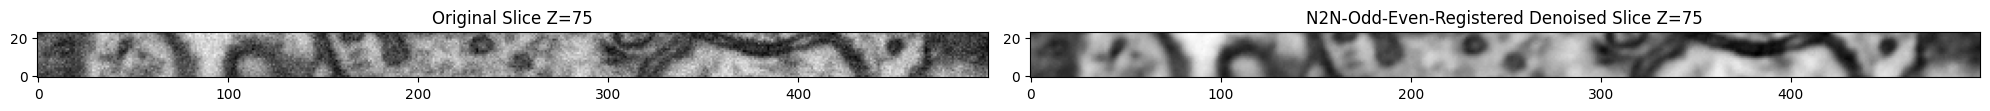

In [22]:
slice_idx = original_vol.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(20, 20))

# Plot the original slice z
im1 = axes[0].imshow(original_vol[slice_idx, 500:1000, 1000:1500].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot the original slice z+1
im2 = axes[1].imshow(denoised_vol[slice_idx, 500:1000, 1000:1500].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()

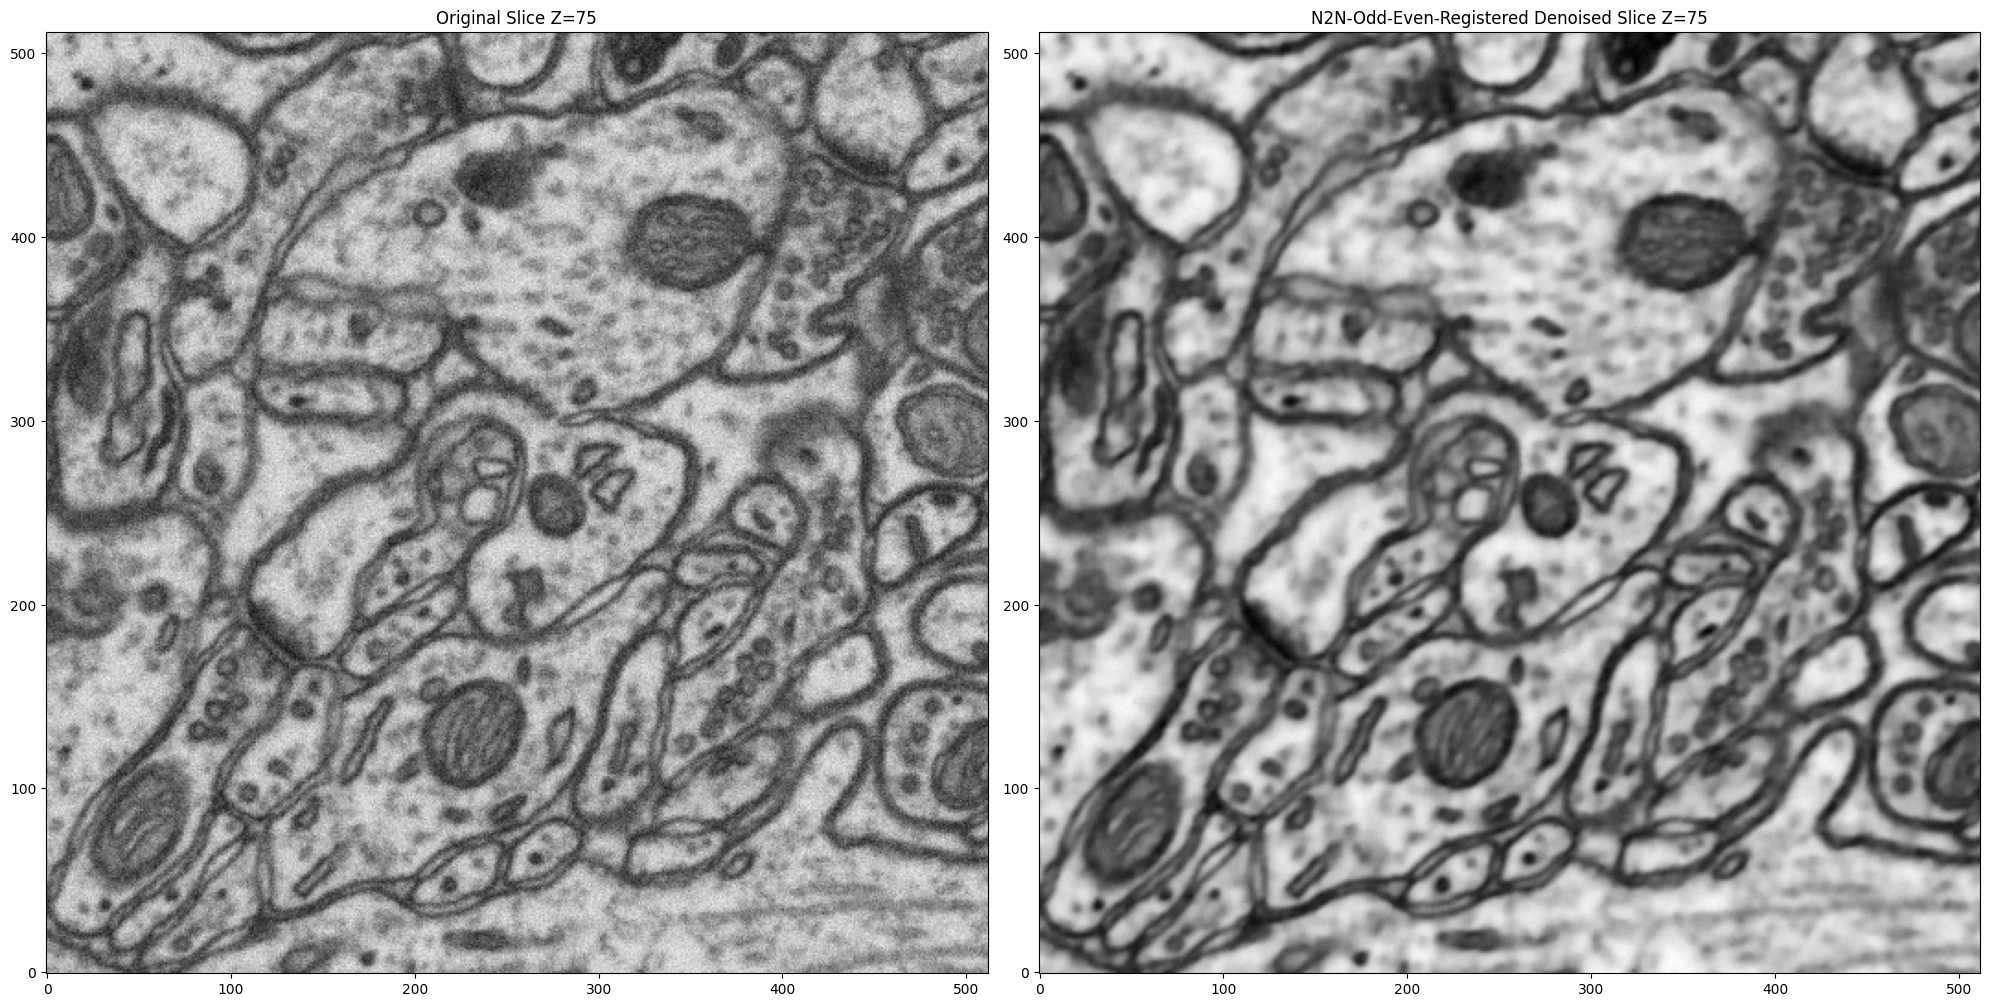

In [23]:
slice_idx = original_vol.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(20, 20))

# Plot the original slice z
im1 = axes[0].imshow(original_vol[slice_idx, 0:512, 0:512].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot the original slice z+1
im2 = axes[1].imshow(denoised_vol[slice_idx, 0:512, 0:512].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even-Registered Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()

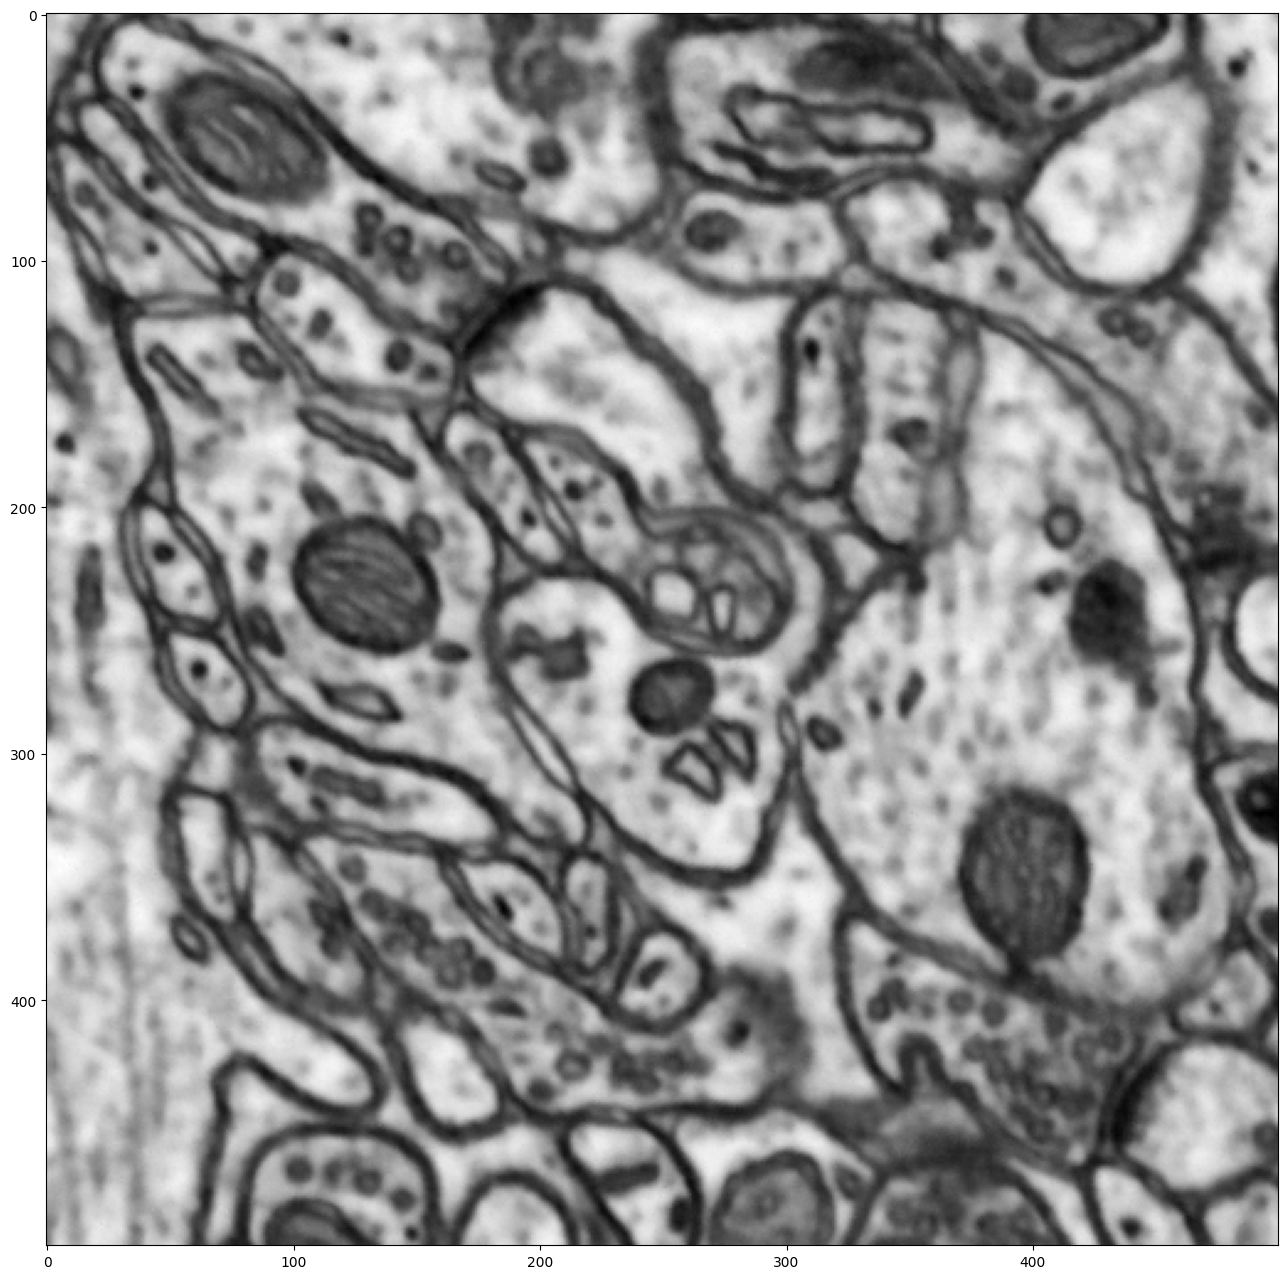

In [24]:
from matplotlib.pyplot import figure
figure(figsize=(16, 16))
slice_idx = denoised_vol.shape[0]//2
plt.imshow(denoised_vol[slice_idx, 0:500, 0:500], cmap="gray")
plt.savefig("denoised.pdf", bbox_inches='tight')